In [1]:
"""
RPLT Code - Integrated Version
Combines original RPLT analysis with John's smoothing and UPM force calculations

Features:
1. Raw acceleration → Scaled (±1g) → Scaled (m/s²)
2. Velocity and Displacement computation via integration
3. Load calculation
4. Weighted smoothing of acceleration
5. UPM Force analysis (Fma and Fkx)
6. Comprehensive plotting
"""

from dataclasses import dataclass
from typing import Iterable, Literal, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --------------------------- Data classes ---------------------------
@dataclass
class AccelCalibration:
    """
    AccelCalibration groups the parameters needed to convert
    raw accelerometer readings into physical units (g).

    Attributes
    ----------
    offset : float
        The raw sensor value that corresponds to 0 g (no acceleration).
        - Example: If your accelerometer outputs 0.345 V when stationary,
          then offset = 0.345.
        - This removes the "bias" of the sensor.

    sens : float
        The sensitivity of the sensor, i.e. how many raw units correspond
        to 1 g (≈ 9.81 m/s²).
        - Example: If a change of 0.065 V corresponds to 1 g, then sens = 0.065.
        - Higher sensitivity → larger raw change for the same acceleration.

    Usage
    -----
    scaled_g = (raw_value - offset) / sens
    scaled_mps2 = scaled_g * 9.81
    """

    offset: float = 0.0   # default: assume no bias in raw readings
    sens: float = 1.0     # default: 1 raw unit = 1 g (no scaling)


@dataclass
class LoadCalibration:
    a: float = 754.717
    b: float = -0.26717


@dataclass
class UPMParameters:
    """Parameters for UPM (Unloading Point Method) force analysis"""
    mass: float = 12000.0        # kg - total system mass
    stiffness: float = 1.397e6   # N/m - equivalent spring stiffness


In [3]:
# --------------------------- Helpers ---------------------
def _ensure_increasing_time(t: np.ndarray, *arrays: np.ndarray) -> Tuple[np.ndarray, ...]:
    """
    Ensure time array is strictly increasing by sorting if necessary.

    This function checks if the time array is monotonically increasing. If not,
    it sorts the time array and reorders all other arrays accordingly to maintain
    data alignment.

    Parameters
    ----------
    t : np.ndarray
        Time array that should be monotonically increasing
    *arrays : np.ndarray
        Additional arrays (e.g., acceleration, load) that correspond to time points
        and need to be sorted in the same order as time

    Returns
    -------
    Tuple[np.ndarray, ...]
        Tuple containing sorted time array followed by all sorted data arrays
        If time was already sorted, returns original arrays unchanged

    Examples
    --------
    >>> time = np.array([0.0, 0.2, 0.1, 0.3])
    >>> accel = np.array([1.0, 2.0, 1.5, 3.0])
    >>> sorted_time, sorted_accel = _ensure_increasing_time(time, accel)
    >>> sorted_time
    array([0.0, 0.1, 0.2, 0.3])
    >>> sorted_accel
    array([1.0, 1.5, 2.0, 3.0])

    Notes
    -----
    - Non-strictly increasing time can occur due to data collection errors
    - Sorting ensures proper integration and analysis
    - All arrays must have the same length as the time array
    """
    if np.any(np.diff(t) <= 0):
        idx = np.argsort(t)
        out = (t[idx],) + tuple(arr[idx] for arr in arrays)
        return out
    return (t,) + arrays


def _cumtrapz_same_length(y: np.ndarray, x: np.ndarray) -> np.ndarray:
    """
    Cumulative trapezoidal integration maintaining original array length.

    Performs numerical integration using the trapezoidal rule, returning an array
    of the same length as the input. The first element is set to 0.0 (initial
    condition), and subsequent elements represent cumulative integral values.

    Mathematical Formula:
    ---------------------
    For integration of y with respect to x:
        integral[i] = sum from j=1 to i of: 0.5 * (y[j] + y[j-1]) * (x[j] - x[j-1])

    Parameters
    ----------
    y : np.ndarray
        Values to integrate (e.g., acceleration to get velocity)
    x : np.ndarray
        Independent variable (e.g., time)
        Must be same length as y

    Returns
    -------
    np.ndarray
        Cumulative integral values, same length as input
        First element is always 0.0
        If input has less than 2 elements, returns array of zeros

    Examples
    --------
    >>> # Integrate constant acceleration to get velocity
    >>> time = np.array([0.0, 1.0, 2.0, 3.0])
    >>> accel = np.array([10.0, 10.0, 10.0, 10.0])  # constant 10 m/s²
    >>> velocity = _cumtrapz_same_length(accel, time)
    >>> velocity
    array([0.0, 10.0, 20.0, 30.0])  # v = at

    >>> # Integrate velocity to get displacement
    >>> displacement = _cumtrapz_same_length(velocity, time)
    >>> displacement
    array([0.0, 5.0, 20.0, 45.0])  # s = 0.5*a*t²

    Notes
    -----
    - Uses trapezoidal rule: more accurate than rectangular approximation
    - Output length matches input length (unlike scipy.integrate.cumtrapz)
    - First value is 0.0 representing initial condition (e.g., v₀ = 0, s₀ = 0)
    - Ideal for converting:
        * Acceleration → Velocity
        * Velocity → Displacement

    See Also
    --------
    scipy.integrate.cumtrapz : Similar but returns n-1 length array
    numpy.trapz : Single integral value rather than cumulative
    """
    n = len(y)
    if n < 2:
        return np.zeros_like(y, dtype=float)

    # Calculate spacing between x values
    dx = np.diff(x)

    # Average of consecutive y values (trapezoidal rule)
    avg = 0.5 * (y[1:] + y[:-1])

    # Initialize output array
    out = np.empty(n, dtype=float)
    out[0] = 0.0  # Initial condition

    # Cumulative sum of area under curve
    out[1:] = np.cumsum(avg * dx)

    return out


def _remove_linear_drift(vec: np.ndarray) -> np.ndarray:
    """
    Remove linear drift from integrated signals (velocity or displacement).

    Integration of noisy acceleration data often produces a linear drift in
    velocity, which then causes quadratic drift in displacement. This function
    removes the linear trend by subtracting a line from the first point (0.0)
    to the last point (vec[-1]), effectively enforcing that the signal ends
    at zero.

    Mathematical Operation:
    ----------------------
    For each point i:
        corrected[i] = vec[i] - (i / (n-1)) * vec[-1]

    where n is the length of the vector.

    Parameters
    ----------
    vec : np.ndarray
        Input signal with linear drift (typically integrated velocity or displacement)
        Should be 1D array

    Returns
    -------
    np.ndarray
        Signal with linear drift removed
        Same shape as input
        First point unchanged (0.0), last point forced to 0.0

    Examples
    --------
    >>> # Velocity with drift
    >>> velocity_with_drift = np.array([0.0, 2.5, 5.2, 8.0, 11.0])
    >>> velocity_corrected = _remove_linear_drift(velocity_with_drift)
    >>> velocity_corrected
    array([0.0, 0.75, 1.45, 2.0, 0.0])  # Last point now zero

    >>> # Check that drift is removed
    >>> velocity_corrected[-1]
    0.0

    Physical Interpretation
    -----------------------
    For RPLT testing:
    - The pile should return approximately to rest after impact
    - Final velocity should be ≈ 0 m/s
    - Final displacement should return near starting position
    - Linear drift correction enforces these physical constraints

    Notes
    -----
    - Commonly used after integrating acceleration to get velocity
    - Assumes the physical process starts and ends near equilibrium
    - Drift typically comes from:
        * Sensor bias/offset
        * Numerical integration errors
        * Low-frequency noise
    - Only corrects LINEAR drift, not higher-order trends
    - For signals shorter than 2 points, returns unchanged

    Warnings
    --------
    Do NOT use this function if:
    - Your signal should NOT end at zero (e.g., permanent displacement)
    - You have significant non-linear drift
    - Your test doesn't return to equilibrium

    See Also
    --------
    scipy.signal.detrend : More general detrending options
    """
    if len(vec) < 2:
        return vec

    # Create linear trend from 0 to final value
    trend = np.linspace(0.0, vec[-1], len(vec))

    # Remove trend
    return vec - trend


def apply_weighted_smoothing(
    data: np.ndarray,
    window: int = 120,
    weight_type: Literal["linear", "exponential", "uniform"] = "linear"
) -> np.ndarray:
    """
    Apply weighted moving average smoothing to data.

    Parameters
    ----------
    data : np.ndarray
        Input data to smooth
    window : int
        Window size for smoothing (default: 120)
    weight_type : str
        Type of weighting:
        - "linear": Recent values weighted more (np.linspace(1, 2, window))
        - "exponential": Exponential weighting (np.geomspace(1, 10, window))
        - "uniform": Simple moving average (np.ones(window))

    Returns
    -------
    np.ndarray
        Smoothed data
    """
    if weight_type == "linear":
        weights = np.linspace(1, 2, window)
    elif weight_type == "exponential":
        weights = np.geomspace(1, 10, window)
    elif weight_type == "uniform":
        weights = np.ones(window)
    else:
        raise ValueError(f"Unknown weight_type: {weight_type}")

    # Normalize weights to sum = 1
    weights = weights / weights.sum()

    # Apply convolution
    smoothed = np.convolve(data, weights, mode="same")

    return smoothed


def compute(
    time: Iterable[float],
    accel_raw: Iterable[float],
    *,
    accel_cal: AccelCalibration = AccelCalibration(),
    use_auto_zero_mean: bool = True,
    g_const: float = 9.81,
    drift_fix_velocity: bool = True,
    load_cal: LoadCalibration = LoadCalibration(),
    load_input: Literal["raw", "scaled_g", "scaled_mps2", "external", "original"] = "raw",
    x_external_for_load: Optional[Iterable[float]] = None,
    load_original: Optional[Iterable[float]] = None,
    apply_smoothing: bool = False,
    smoothing_window: int = 120,
    smoothing_type: Literal["linear", "exponential", "uniform"] = "linear",
    upm_params: Optional[UPMParameters] = None,
) -> pd.DataFrame:
    """
    Compute Scaled (+/-1g), Scaled (m/s^2), Velocity, Disp, Load, and optionally UPM forces.

    Parameters
    ----------
    time : Iterable[float]
        Time values in seconds
    accel_raw : Iterable[float]
        Raw acceleration readings
    accel_cal : AccelCalibration
        Calibration parameters for acceleration
    use_auto_zero_mean : bool
        If True, auto-zero the raw acceleration (default: True)
    g_const : float
        Gravitational constant (default: 9.81 m/s²)
    drift_fix_velocity : bool
        If True, remove linear drift from velocity (default: True)
    load_cal : LoadCalibration
        Calibration parameters for load calculation
    load_input : str
        Which signal to use for load calculation
    x_external_for_load : Optional[Iterable[float]]
        External signal for load calculation
    load_original : Optional[Iterable[float]]
        Original load values (if available)
    apply_smoothing : bool
        If True, apply weighted smoothing to acceleration (default: False)
    smoothing_window : int
        Window size for smoothing (default: 120)
    smoothing_type : str
        Type of smoothing weights (default: "linear")
    upm_params : Optional[UPMParameters]
        Parameters for UPM force analysis (if None, UPM forces not computed)

    Returns
    -------
    pd.DataFrame
        DataFrame containing all computed values
    """
    t = np.asarray(time, dtype=float)
    raw = np.asarray(accel_raw, dtype=float)

    if t.size != raw.size:
        raise ValueError("time and accel_raw must have the same length.")
    if t.size < 2:
        raise ValueError("Need at least 2 samples to integrate.")

    # Sort if needed
    t, raw = _ensure_increasing_time(t, raw)

    # Raw -> g
    if use_auto_zero_mean:
        scaled_g = raw - np.nanmean(raw)
    else:
        scaled_g = (raw - accel_cal.offset) / accel_cal.sens

    # g -> m/s^2
    a_mps2 = scaled_g * g_const

    # Apply smoothing if requested
    if apply_smoothing:
        a_mps2_smoothed = apply_weighted_smoothing(a_mps2, smoothing_window, smoothing_type)
    else:
        a_mps2_smoothed = a_mps2.copy()

    # Integrate a -> v
    v = _cumtrapz_same_length(a_mps2, t)
    if drift_fix_velocity:
        v = _remove_linear_drift(v)

    # Integrate v -> disp
    disp = _cumtrapz_same_length(v, t)

    # Choose x for load
    if load_input == "raw":
        x_for_load = raw
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "scaled_g":
        x_for_load = scaled_g
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "scaled_mps2":
        x_for_load = a_mps2
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "external":
        if x_external_for_load is None:
            raise ValueError("Provide x_external_for_load for external load input")
        x_for_load = np.asarray(x_external_for_load, dtype=float)
        _, x_for_load = _ensure_increasing_time(t, x_for_load)
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "original":
        if load_original is None:
            raise ValueError("Provide load_original when load_input='original'")
        load = np.asarray(load_original, dtype=float)
        _, load = _ensure_increasing_time(t, load)
    else:
        raise ValueError("Invalid load_input option")

    # Build output dataframe
    result = pd.DataFrame({
        "Time (s)": t,
        "Acceleration raw": raw,
        "Load": load,
        "Scaled (+/-1g)": scaled_g,
        "Scaled (m/s2)": a_mps2,
        "Velocity (m/s)": v,
        "Disp (m)": disp,
    })

    # Add smoothed acceleration if requested
    if apply_smoothing:
        result["Scaled (m/s2) Smoothed"] = a_mps2_smoothed

    # Add UPM force calculations if parameters provided
    if upm_params is not None:
        # Use smoothed acceleration for force if available, otherwise use raw
        accel_for_force = a_mps2_smoothed if apply_smoothing else a_mps2

        # Compute inertial force: F_ma = m * a
        result["Fma (N)"] = upm_params.mass * accel_for_force

        # Compute elastic/stiffness force: F_kx = k * x
        result["Fkx (N)"] = upm_params.stiffness * disp

        # Total force (if needed for UPM analysis)
        result["Total Force (N)"] = result["Fma (N)"] + result["Fkx (N)"]

        # Convert to kN for easier interpretation
        result["Fma (kN)"] = result["Fma (N)"] / 1000
        result["Fkx (kN)"] = result["Fkx (N)"] / 1000
        result["Total Force (kN)"] = result["Total Force (N)"] / 1000

    return result


def create_plots(df: pd.DataFrame, include_upm: bool = False):
    """
    Create comprehensive plots for RPLT analysis.

    Parameters
    ----------
    df : pd.DataFrame
        Processed data from compute()
    include_upm : bool
        If True, create UPM-specific plots
    """

    # Plot 1: Dual-axis line chart (Acceleration & Load)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(df['Time (s)'], df['Acceleration raw'], color='blue', label="Acceleration")
    ax2.plot(df['Time (s)'], df['LOAD'] if 'LOAD' in df.columns else df['Load'],
             color='green', label="Load")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Acceleration (raw)", color='blue')
    ax2.set_ylabel("Load", color='green')
    plt.title("Acceleration & Load over Time")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.savefig('accel_load_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 2: Histograms
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['Acceleration raw'], kde=True, color='blue')
    plt.title("Acceleration Distribution")
    plt.subplot(1, 2, 2)
    sns.histplot(df['LOAD'] if 'LOAD' in df.columns else df['Load'], kde=True, color='green')
    plt.title("Load Distribution")
    plt.tight_layout()
    plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 3: Load vs Displacement
    plt.figure(figsize=(8, 6))
    plt.plot(df["Disp (m)"], df['LOAD'] if 'LOAD' in df.columns else df['Load'],
             label="Load vs Displacement", color="steelblue")
    plt.title("Load vs Displacement")
    plt.xlabel("Displacement (m)")
    plt.ylabel("Load")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig('load_displacement.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 4: Velocity & Displacement vs Time
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    ax1.plot(df["Time (s)"], df["Velocity (m/s)"], color="blue", label="Velocity")
    ax2.plot(df["Time (s)"], df["Disp (m)"], color="orange", label="Displacement")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Velocity (m/s)", color="blue")
    ax2.set_ylabel("Displacement (m)", color="orange")
    plt.title("Velocity & Displacement vs Time")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.savefig('velocity_displacement_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 5: Acceleration & Displacement vs Time
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    ax1.plot(df["Time (s)"], df["Scaled (m/s2)"], color="red", label="Acceleration")
    ax2.plot(df["Time (s)"], df["Disp (m)"], color="purple", label="Displacement")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Acceleration (m/s²)", color="red")
    ax2.set_ylabel("Displacement (m)", color="purple")
    plt.title("Acceleration & Displacement vs Time")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.savefig('accel_displacement_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 6: Load & Displacement vs Time (with filled areas)
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    ax1.plot(df["Time (s)"], df['LOAD'] if 'LOAD' in df.columns else df['Load'],
             color="green", label="Load")
    ax1.fill_between(df["Time (s)"], df['LOAD'] if 'LOAD' in df.columns else df['Load'],
                     color="green", alpha=0.2)
    ax2.plot(df["Time (s)"], df["Disp (m)"], color="brown", label="Displacement")
    ax2.fill_between(df["Time (s)"], df["Disp (m)"], color="brown", alpha=0.2)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Load", color="green")
    ax2.set_ylabel("Displacement (m)", color="brown")
    plt.title("Load & Displacement vs Time")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.savefig('load_displacement_time_filled.png', dpi=300, bbox_inches='tight')
    plt.show()

    # UPM-specific plots
    if include_upm and "Fma (kN)" in df.columns:
        # Plot 7: UPM Force-Displacement Curve
        plt.figure(figsize=(10, 6))
        plt.plot(df["Disp (m)"] * 1000, df["Fma (kN)"],
                label="Inertial Force (Fma)", color="steelblue", linewidth=2)
        plt.plot(df["Disp (m)"] * 1000, df["Fkx (kN)"],
                label="Elastic Force (Fkx)", color="orange", linewidth=2)
        plt.plot(df["Disp (m)"] * 1000, df["Total Force (kN)"],
                label="Total Force", color="red", linewidth=2, linestyle="--")
        plt.xlabel("Displacement (mm)")
        plt.ylabel("Force (kN)")
        plt.title("UPM Force-Displacement Curve")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.savefig('upm_force_displacement.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Plot 8: Force components vs Time
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(df["Time (s)"], df["Fma (kN)"], label="Inertial Force (Fma)", linewidth=2)
        ax.plot(df["Time (s)"], df["Fkx (kN)"], label="Elastic Force (Fkx)", linewidth=2)
        ax.plot(df["Time (s)"], df["Total Force (kN)"],
               label="Total Force", linewidth=2, linestyle="--")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Force (kN)")
        ax.set_title("UPM Force Components vs Time")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend()
        plt.tight_layout()
        plt.savefig('upm_forces_time.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Plot 9: Smoothed vs Unsmoothed Acceleration (if smoothing was applied)
        if "Scaled (m/s2) Smoothed" in df.columns:
            plt.figure(figsize=(10, 6))
            plt.plot(df["Time (s)"], df["Scaled (m/s2)"],
                    label="Raw Acceleration", alpha=0.5, linewidth=1)
            plt.plot(df["Time (s)"], df["Scaled (m/s2) Smoothed"],
                    label="Smoothed Acceleration", linewidth=2)
            plt.xlabel("Time (s)")
            plt.ylabel("Acceleration (m/s²)")
            plt.title("Acceleration: Raw vs Smoothed")
            plt.grid(True, linestyle="--", alpha=0.6)
            plt.legend()
            plt.tight_layout()
            plt.savefig('accel_comparison.png', dpi=300, bbox_inches='tight')
            plt.show()

In [4]:
# The direct URL to the Google Sheet in Excel format
excel_url = "https://docs.google.com/spreadsheets/d/1Csn1iphLRz7F4G-tQlQK0chsvVh6_K_pV6Nl3Xe2J4U/export?gid=0#gid=0"

In [5]:
print("Loading data from Google Sheets...")
# Use pandas to read the Excel file directly from th`e URL
df = pd.read_excel(excel_url, engine='openpyxl')

Loading data from Google Sheets...


In [6]:
# Create the initial Excel file with the original data
print("Creating initial Excel file with raw data...")
with pd.ExcelWriter('RPLTResults.xlsx') as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

Creating initial Excel file with raw data...


In [7]:
print("Original data preview:")
print(df.head())

Original data preview:
   Time (s)  Acceleration raw    LOAD
0  6.920039          0.001444  86.790
1  6.920098          0.001163  84.255
2  6.920156          0.001129  86.790
3  6.920215          0.001463  84.285
4  6.920273          0.001571  86.790


In [8]:
# Extract data for processing
time = df['Time (s)'].to_list()
accel_raw = df['Acceleration raw'].to_list()
load_original = df['LOAD'].to_list()

In [9]:
# ========== BASIC PROCESSING (No Smoothing, No UPM) ==========
print("\n" + "="*60)
print("BASIC PROCESSING - Original Method")
print("="*60)


BASIC PROCESSING - Original Method


In [10]:
df_basic = compute(
    time,
    accel_raw,
    use_auto_zero_mean=True,
    load_input="original",
    load_original=load_original
)

print("\nBasic processing results:")
print(df_basic.head())


Basic processing results:
   Time (s)  Acceleration raw    Load  Scaled (+/-1g)  Scaled (m/s2)  \
0  6.920039          0.001444  86.790        0.001144       0.011222   
1  6.920098          0.001163  84.255        0.000863       0.008465   
2  6.920156          0.001129  86.790        0.000829       0.008132   
3  6.920215          0.001463  84.285        0.001163       0.011408   
4  6.920273          0.001571  86.790        0.001271       0.012468   

   Velocity (m/s)      Disp (m)  
0    0.000000e+00  0.000000e+00  
1    5.808176e-07  1.713412e-11  
2    1.062177e-06  6.478097e-11  
3    1.638654e-06  1.444555e-10  
4    2.331105e-06  2.595785e-10  


In [11]:
# ========== WITH SMOOTHING (John's Method) ==========
print("\n" + "="*60)
print("WITH SMOOTHING - John's Weighted Moving Average Method")
print("="*60)

df_smoothed = compute(
    time,
    accel_raw,
    use_auto_zero_mean=True,
    load_input="original",
    load_original=load_original,
    apply_smoothing=True,
    smoothing_window=120,
    smoothing_type="linear"  # Can be: "linear", "exponential", "uniform"
)

print("\nSmoothed processing results:")
print(df_smoothed.head())


WITH SMOOTHING - John's Weighted Moving Average Method

Smoothed processing results:
   Time (s)  Acceleration raw    Load  Scaled (+/-1g)  Scaled (m/s2)  \
0  6.920039          0.001444  86.790        0.001144       0.011222   
1  6.920098          0.001163  84.255        0.000863       0.008465   
2  6.920156          0.001129  86.790        0.000829       0.008132   
3  6.920215          0.001463  84.285        0.001163       0.011408   
4  6.920273          0.001571  86.790        0.001271       0.012468   

   Velocity (m/s)      Disp (m)  Scaled (m/s2) Smoothed  
0    0.000000e+00  0.000000e+00                0.003781  
1    5.808176e-07  1.713412e-11                0.003865  
2    1.062177e-06  6.478097e-11                0.003940  
3    1.638654e-06  1.444555e-10                0.004010  
4    2.331105e-06  2.595785e-10                0.004082  


In [12]:
# ========== WITH UPM FORCE ANALYSIS (John's Second Method) ==========
print("\n" + "="*60)
print("WITH UPM FORCE ANALYSIS - John's UPM Method")
print("="*60)

# Define UPM parameters
upm_params = UPMParameters(
    mass=12000.0,       # kg - adjust based on your system
    stiffness=1.397e6   # N/m - adjust based on your system
)

df_upm = compute(
    time,
    accel_raw,
    use_auto_zero_mean=True,
    load_input="original",
    load_original=load_original,
    apply_smoothing=True,
    smoothing_window=120,
    smoothing_type="linear",
    upm_params=upm_params
)

print("\nUPM processing results:")
print(df_upm.head())
print("\nUPM Force Statistics:")
print(f"Max Inertial Force (Fma): {df_upm['Fma (kN)'].max():.2f} kN")
print(f"Max Elastic Force (Fkx): {df_upm['Fkx (kN)'].max():.2f} kN")
print(f"Max Total Force: {df_upm['Total Force (kN)'].max():.2f} kN")



WITH UPM FORCE ANALYSIS - John's UPM Method

UPM processing results:
   Time (s)  Acceleration raw    Load  Scaled (+/-1g)  Scaled (m/s2)  \
0  6.920039          0.001444  86.790        0.001144       0.011222   
1  6.920098          0.001163  84.255        0.000863       0.008465   
2  6.920156          0.001129  86.790        0.000829       0.008132   
3  6.920215          0.001463  84.285        0.001163       0.011408   
4  6.920273          0.001571  86.790        0.001271       0.012468   

   Velocity (m/s)      Disp (m)  Scaled (m/s2) Smoothed    Fma (N)   Fkx (N)  \
0    0.000000e+00  0.000000e+00                0.003781  45.370229  0.000000   
1    5.808176e-07  1.713412e-11                0.003865  46.377835  0.000024   
2    1.062177e-06  6.478097e-11                0.003940  47.275574  0.000090   
3    1.638654e-06  1.444555e-10                0.004010  48.123949  0.000202   
4    2.331105e-06  2.595785e-10                0.004082  48.981365  0.000363   

   Total Force (

In [13]:
# ========== SAVE ALL RESULTS ==========
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

with pd.ExcelWriter('RPLTResults.xlsx', mode='a', engine='openpyxl') as writer:
    df_basic.to_excel(writer, sheet_name='basic_results', index=False)
    df_smoothed.to_excel(writer, sheet_name='smoothed_results', index=False)
    df_upm.to_excel(writer, sheet_name='upm_results', index=False)

print("✓ Results saved to RPLTResults.xlsx with multiple sheets:")
print("  - Sheet1: Original raw data")
print("  - basic_results: Basic processing (no smoothing)")
print("  - smoothed_results: With smoothing applied")
print("  - upm_results: With smoothing and UPM force analysis")


SAVING RESULTS
✓ Results saved to RPLTResults.xlsx with multiple sheets:
  - Sheet1: Original raw data
  - basic_results: Basic processing (no smoothing)
  - smoothed_results: With smoothing applied
  - upm_results: With smoothing and UPM force analysis



CREATING PLOTS

Generating comprehensive plots...


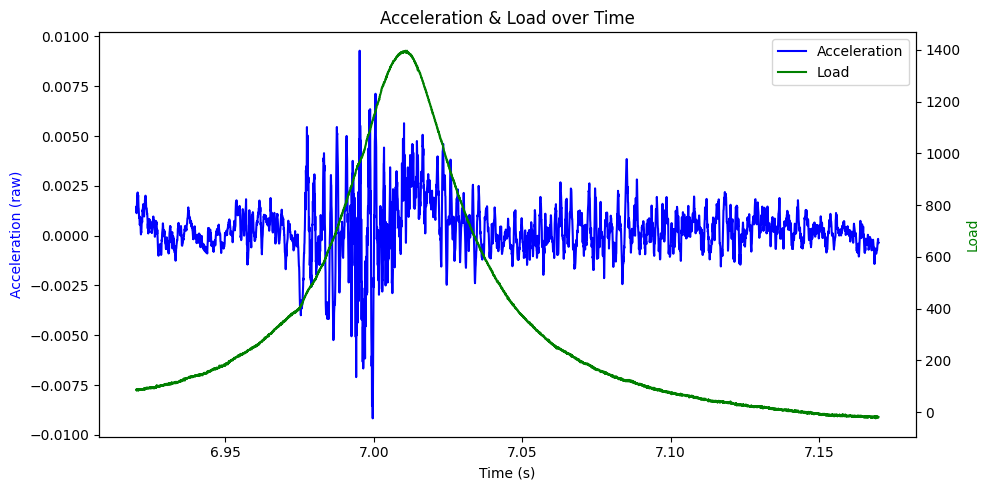

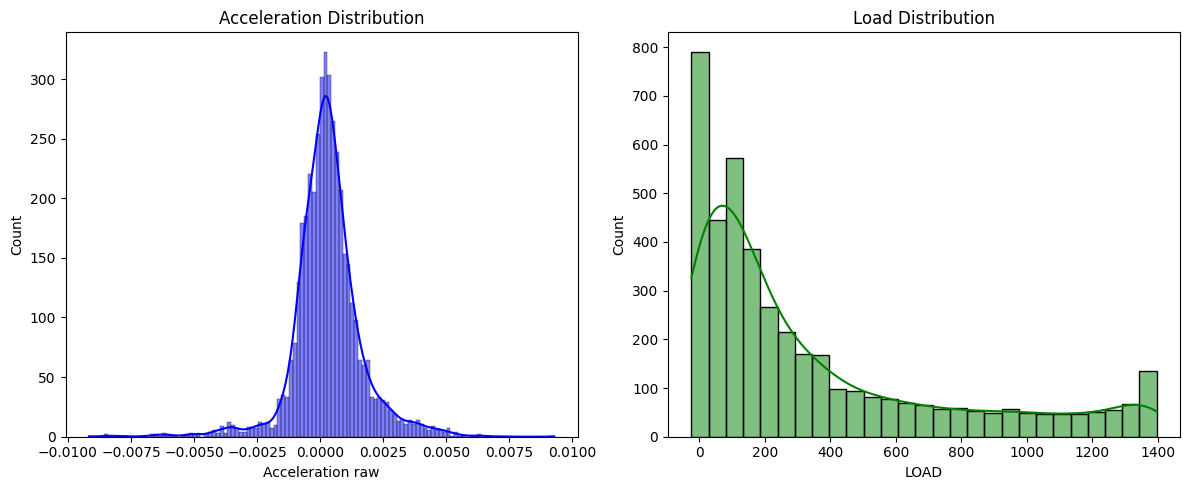

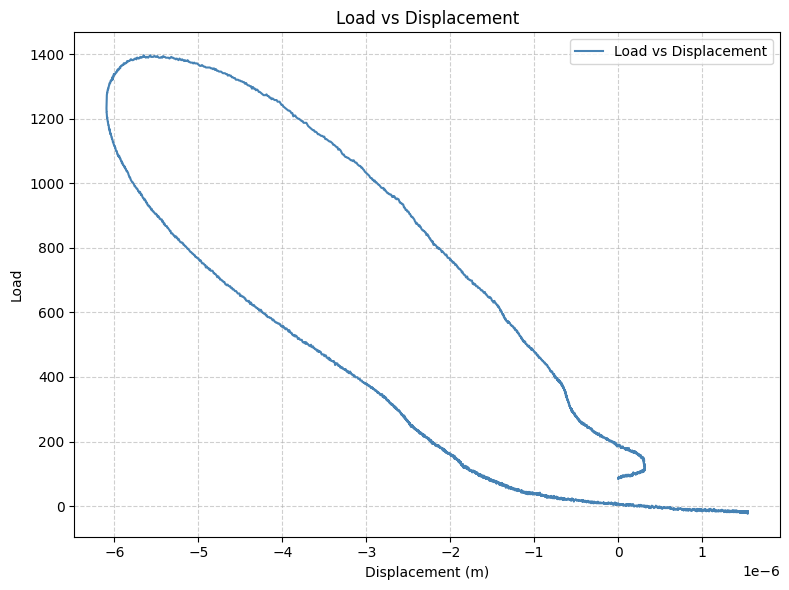

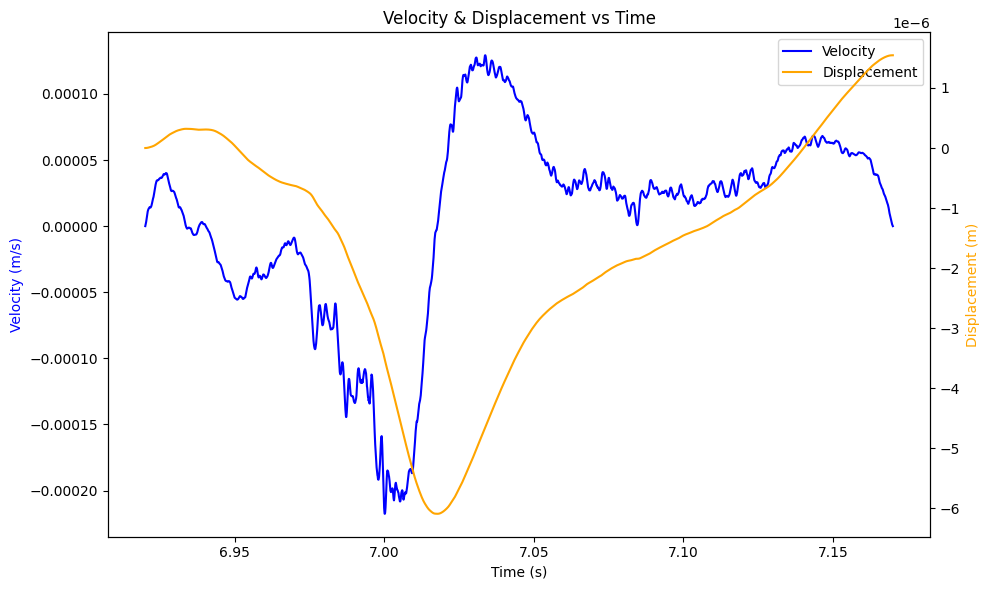

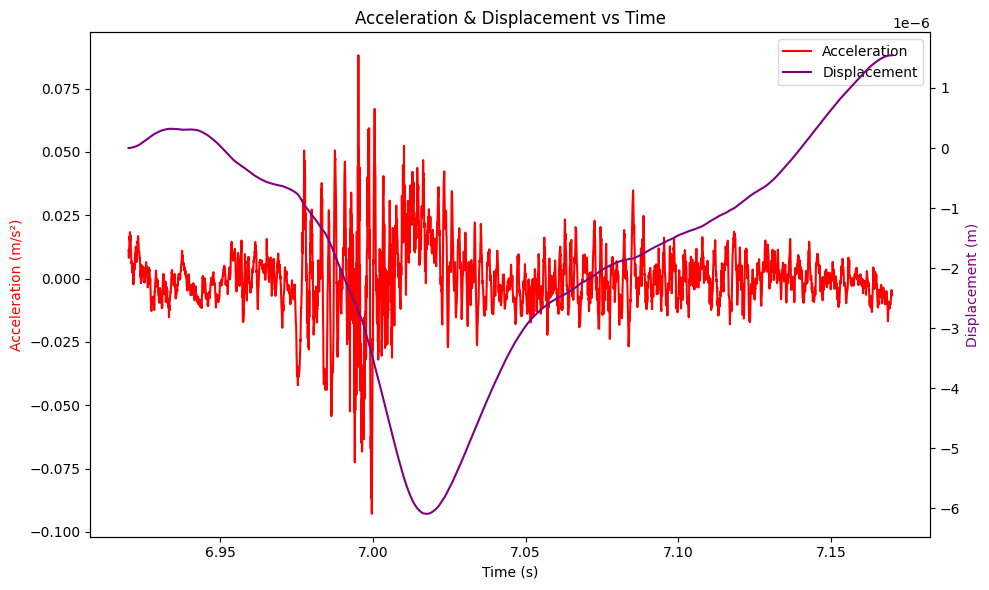

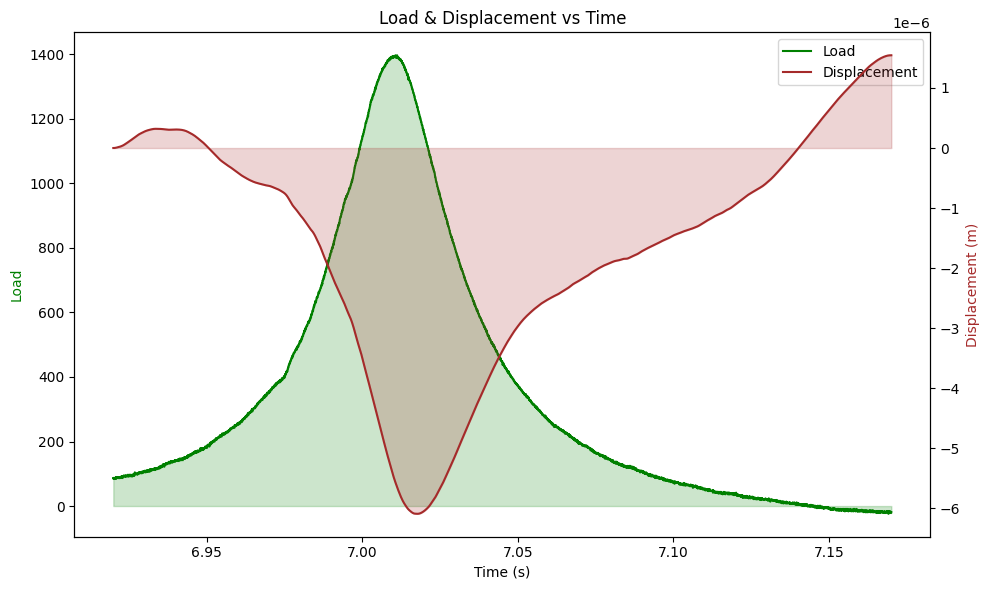

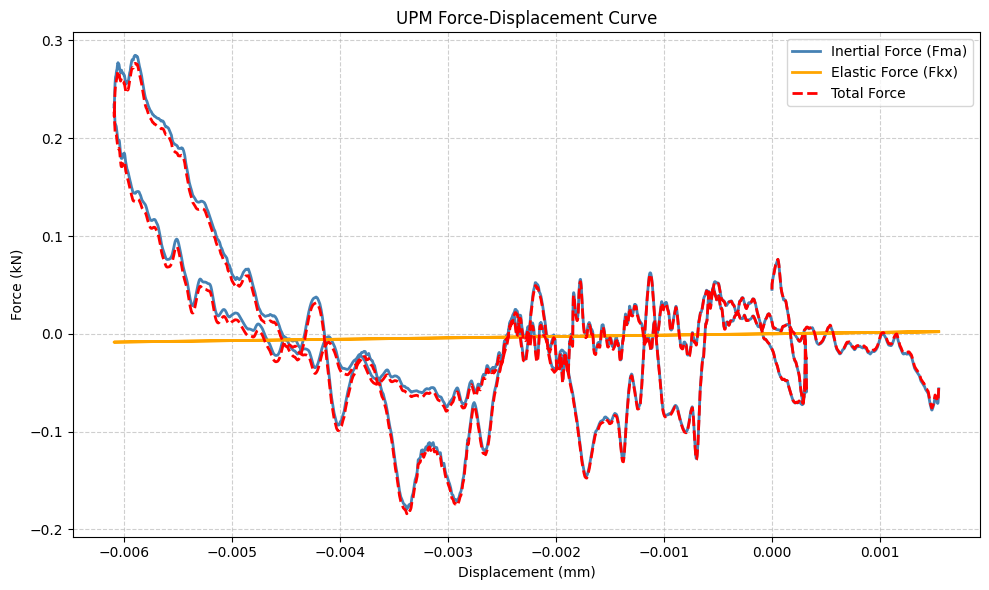

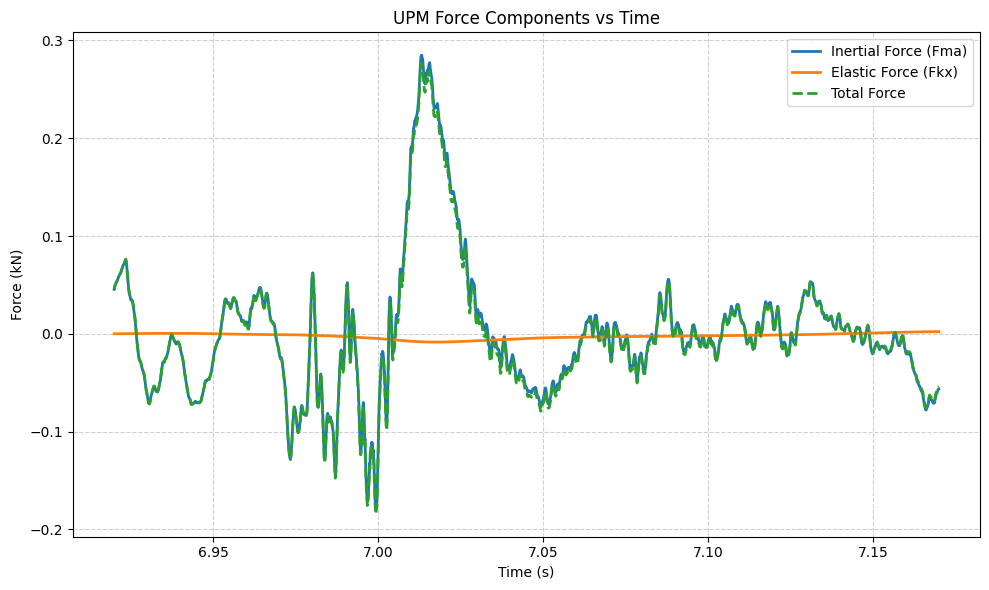

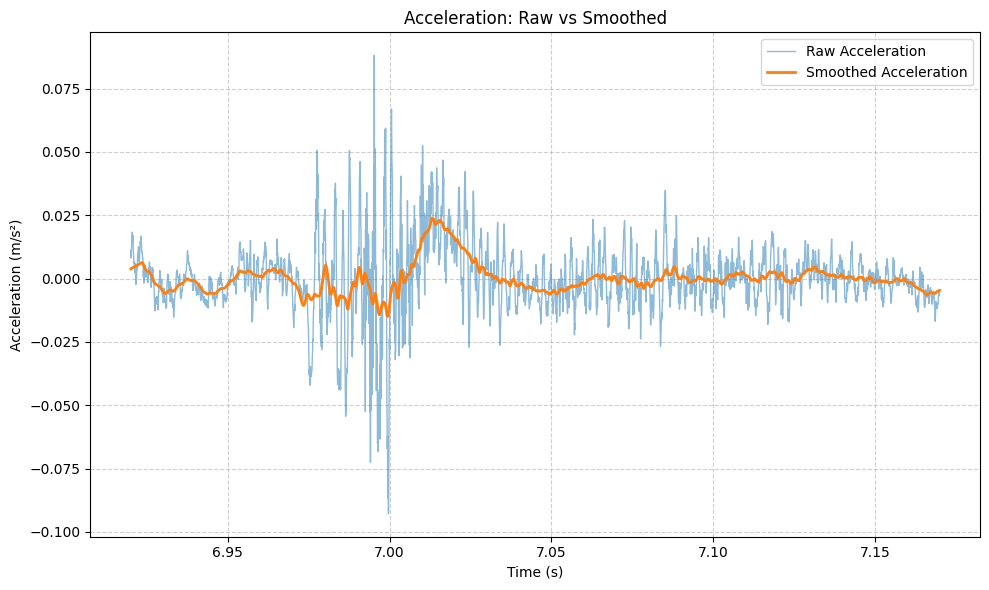


PROCESSING COMPLETE!
  - RPLTResults.xlsx (Excel file with all results)
  - Multiple PNG plots for visualization


In [14]:
# ========== CREATE PLOTS ==========
print("\n" + "="*60)
print("CREATING PLOTS")
print("="*60)

# Add LOAD column to df_upm for plotting compatibility
df_upm['LOAD'] = load_original

print("\nGenerating comprehensive plots...")
create_plots(df_upm, include_upm=True)

print("\n" + "="*60)
print("PROCESSING COMPLETE!")
print("="*60)
print("  - RPLTResults.xlsx (Excel file with all results)")
print("  - Multiple PNG plots for visualization")